# K-Armed-Bandit 

- Author: Ethan Cao
- Description: HW solution for the k-armed-bandit problem with simple reinforcement learning algorithm, with the replication of visualizations on the book chapter 2.2 - 2.6

## Bandit Environment
- We first define the environment of the multi-armed bandit game with its **reward distributions**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class BanditEnvironment:
    # constructor for all the variables in this game
    def __init__(self, k=10, seed=None):
        # k number of arms that this bandit game has
        self.k = k
        # defining a random number generator with a set seed
        self.rng = np.random.default_rng(seed)
        # defining the true distribution of the reward
        # samples one true expected reward per arm from N(0, 1), mean 0 and std 1
        self.q_t = self.rng.normal(loc=0, scale=1, size=k)
        # define the variable that stores the index of the arm with the highest true expected reward
        self.optimal_action = np.argmax(self.q_t)

    # function that generates a reward each step
    def step(self, action):
        # samples a reward centered on the arm's true value with std 1
        return self.rng.normal(loc=self.q_t[action], scale=1)


- In the code above, when we create an environment, we generate one true mean reward for each arm: `self.q_t = self.rng.normal(loc=0, scale=1, size=k)`
- for example, for three arms, we get: `self.q_t = np.array([0.2, -0.8, 1.5])`
                                                             
                                                         0     1    2
- These numbers describe how *rewarding* each arm is on average.
- Each time an arm is selected, we generate a new reward: `return self.rng.normal(loc=self.q_t[action], scale=1)`
- if `action = 2`, meaning we chose the second index arm, the code finds the normal distribution of rewards centered around index 2 arm's mean true reward (which is `1.5`). By **repeatedly** sampling from this distribution, or selecting arm 2, the average of those sampled rewards gradually approaches `1.5`. This is also referred by the **law of big numbers**.
- for example, repeatedly sampling a normal distribution centered around index 2 arm's mean, we get `1.9`, `0.6`, and `2.1`, ... and averaging those would gradually approach `1.5`.

## The 'Not so' Greedy Agent
- Here we initialize the 'AI Agent' who will be playing the game and optimizing its result based on the rewards it receives.
- We define the agent to use a strategy of not purely being *Greedy*. Instead, we define an `epsilon` variable that determines to what percentage of times would the agent choose an arm at random that *does not* return the most rewards. 

In [3]:
class NotSoGreedyAgent:
    def __init__(self, k=10, epsilon=0.1, seed=None):
        self.k = k
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)

        # creates an array of k numbers of 0s initially
        # these will later be stored with the estimated mean reward per arm.
        self.Q = np.zeros(k)

        # creates an array of arm selection count per arm (in integer)
        self.N = np.zeros(k, dtype=int)

    # a method defines the rule for choosing an arm
    def select_action(self):

        # # the rule to conduct exploration instead of exploitation:
        # # if the randomly drawn probability is between 0.0 to 0.1, execute the exploration strategy
        # if self.rng.random() < self.epsilon:
        #     # randomly choose an arm 
        #     return self.rng.integers(self.k)

        # # otherwise, if the randomly drawn value is between 0.1 to 1.0, execute the greedy strategy
        # # finds the indicies of all arms tied for the highest estimated reward
        # best_actions = np.flatnonzero(self.Q == self.Q.max())


        # # exploits by choosing randomly among those best arms in a greedy manner
        # return self.rng.choice(best_actions)

        # picks the arm choosing strategy based on the existing probability
        decision = self.rng.choice(["explore","greedy"], p=[self.epsilon, 1-self.epsilon])
        if decision == "explore":
            # randomly choose an arm
            return self.rng.integers(self.k)
        else:
            # np.flatnonzero() returns indices where an array's values are nonzero
            # here we return non zero indices of arm reward values that are equal to the max reward of this array
            best_actions = np.flatnonzero(self.Q == self.Q.max())
            # randomly picks one of the tied arms (if any)
            return self.rng.choice(best_actions)

    # a method that receives the chosen arm and its current estimated/observed reward
    def update(self, action, reward):
        # update the number of times this (chosen) arm has been chosen
        self.N[action] += 1
        # update the estimated mean reward for that particular chosen arm
        # calculated as: the difference between observed reward and the current estimated reward / the number of times the arm is chosen
        self.Q[action] += (reward - self.Q[action])/self.N[action]

- As shown above, we also define the agent with the variable `Q` that records the mean estimated reward for each arm at each step, and the variable `N` records the number of times each arm is selected since the start for each arm at each step.
- we define a method `select_action` that selects an arm based on the define `epsilon` that will influence the probability of choosing and making the agent *less greedy*
- we define a method `update` that determines how the next step estimated reward is calculated:
$$New \ estimate = old \ estimate + \frac{observed \ reward - old \ estimate}{num \ of \ times \ this \ arm \ was \ chosen}$$

## Training Loop
- Finally, we reach the training loop, we will be defining a loop as to how many steps should the multi-armed bandit game to be played, and observe the trained output

In [4]:
def training_loop(epsilon, steps=1000, k=10):
    # creates a new bandit environment with randomly generated true arm means 
    environment = BanditEnvironment(k=k)
    # creates a new agent with zero estimates and counts 
    agent = NotSoGreedyAgent(k=k, epsilon=epsilon)
    # allocate space for each step's reward
    # since at each step, only one arm is chosen, only one reward is produced
    rewards = np.zeros(steps)
    # allocates space to record whether each choice was optimal
    optimal_actions = np.zeros(steps)

    for i in range(steps):
        # ask the agent to choose an arm
        action = agent.select_action()
        # compute the reward from that choice of the arm
        reward = environment.step(action)
        # lets the agent to learn from the observation and update its estimated reward for each chosen arm
        agent.update(action, reward)
        # record this step's reward
        rewards[i] = reward
        # records 1 if the selected arm has the highest true mean, otherwise 0
        optimal_actions[i] = action==environment.optimal_action
    return rewards, optimal_actions

- As seen above, we collect the chosen arm's reward as well as whether that action is an an optimal action is to plot a visualization of how the agent learns over the 2000 runs in the next part.

In [5]:
# define an experiment that runs for 2000 ones, with each run running 1000 steps
def run_experiment(epsilons=(0, 0.01, 0.1), runs=2000, steps=1000):
    # creates an array of (3, 1000), one row per epsilon and one column per step
    average_rewards = np.zeros((len(epsilons), steps))
    # same layout but for optimal actions result
    optimal_percentages = np.zeros((len(epsilons), steps))

    # loops through epsilons with i as the row index
    for i, epsilon in enumerate(epsilons):
        # repeat each epsilon's experiment 2000 times
        for run in range(runs):
            # fetch the rewards and optimal actions list from each run
            rewards, optimal_actions = training_loop(epsilon=epsilon, steps=steps)
            # adds the reward array to that epsilon's row per step
            average_rewards[i] += rewards
            # counts how many runs selected the optimal arm at each step
            optimal_percentages[i] += optimal_actions
        # calculate average rewards at that epsilon from 1000 steps across all runs
        average_rewards[i] /= runs
        # calculate the 
        optimal_percentages[i] *= 100/runs
    return average_rewards, optimal_percentages

### How rewards accumulate across runs

Suppose we use three epsilon settings, four steps per run, and two runs per setting.

Each **row** corresponds to an epsilon value, and each **column** corresponds to a step:

$$
\text{average\_rewards}
=
\begin{bmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
\quad
\begin{array}{l}
\leftarrow \epsilon = 0 \\
\leftarrow \epsilon = 0.01 \\
\leftarrow \epsilon = 0.1
\end{array}
$$

For $i=0$, we update only the first row.

**Run 1:** Suppose the observed rewards are $[1, 2, 0, 3]$.

The operation `average_rewards[i] += rewards` adds corresponding elements:

$$
[0,0,0,0] + [1,2,0,3] = [1,2,0,3].
$$

The array becomes:

$$
\text{average\_rewards}
=
\begin{bmatrix}
1 & 2 & 0 & 3 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}.
$$

**Run 2:** Suppose the observed rewards are $[-1, 1, 2, 1]$.

We add them to the same row:

$$
[1,2,0,3] + [-1,1,2,1] = [0,3,2,4].
$$

The array becomes:

$$
\text{average\_rewards}
=
\begin{bmatrix}
0 & 3 & 2 & 4 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}.
$$

**Average across runs:** After both runs, `average_rewards[i] /= runs` divides the first row by $2$:

$$
\frac{[0,3,2,4]}{2} = [0,1.5,1,2].
$$

Therefore:

$$
\text{average\_rewards}
=
\begin{bmatrix}
0 & 1.5 & 1 & 2 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}.
$$

Next, $i=1$, and we repeat the process for the second row.

During accumulation, each row stores **sums across runs**. After division, it stores the **average reward at each step**. Array addition adds matching elements; it does not append new entries.

## Run experiment
- next, we finally initiate the experiment and watch the final returned rewards and optimal action percentage matrix

In [ ]:
epsilons = (0, 0.01, 0.1)

average_rewards, optimal_percentages = run_experiment(
    epsilons=epsilons,
    runs=2000,
    steps=1000
)

array([[ 0.03040604,  0.30873604,  0.39929064, ...,  1.00684625,
         1.04777314,  1.02589686],
       [-0.01232315,  0.2224881 ,  0.40572069, ...,  1.33348389,
         1.38190942,  1.34357183],
       [ 0.05920571,  0.21460766,  0.34332738, ...,  1.35609193,
         1.34645133,  1.34810628]], shape=(3, 1000))

In [8]:
with np.printoptions(precision=3, suppress=True):
    print(average_rewards)

[[ 0.03   0.309  0.399 ...  1.007  1.048  1.026]
 [-0.012  0.222  0.406 ...  1.333  1.382  1.344]
 [ 0.059  0.215  0.343 ...  1.356  1.346  1.348]]


In [9]:
with np.printoptions(precision=3, suppress=True):
    print(optimal_percentages)

[[11.95 15.5  18.75 ... 37.   37.   37.  ]
 [ 9.95 14.45 17.4  ... 61.05 61.35 61.3 ]
 [ 9.95 12.45 15.15 ... 79.05 80.   79.35]]


## Visualization
- replicating the two graphs from chapter 2, we visualize how, by choosing different epsilons, which corresponds to choosing how much to explore versus being greedy, the reward progresses throughout the steps that is averaged from 2000 runs.

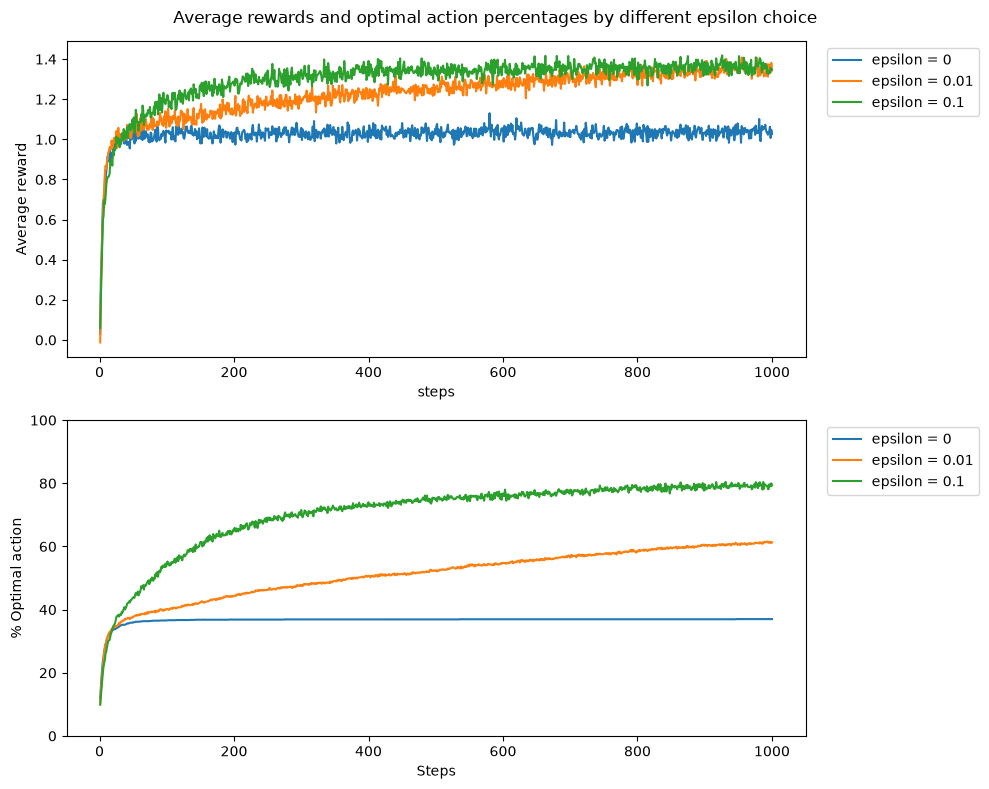

In [17]:
steps = np.arange(1, average_rewards.shape[1] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('Average rewards and optimal action percentages by different epsilon choice')
for i, epsilon in enumerate(epsilons):
    label = f'epsilon = {epsilon}'
    axes[0].plot(steps, average_rewards[i], label=label)
    axes[1].plot(steps, optimal_percentages[i], label=label)
axes[0].set_xlabel('steps')
axes[0].set_ylabel('Average reward')
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1))

axes[1].set_xlabel("Steps")
axes[1].set_ylabel("% Optimal action")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))


plt.tight_layout()
plt.show()

- As shown above, a completely greedy method is often the suboptimal strategy for the agent to achieve higher average reward, nor does it achieve higher optimal action chosen percentage in the long run.